In [15]:
import warnings
import logging
import transformers

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()

In [16]:
# loading dataset
from datasets import load_dataset

# data processing
import pandas as pd
import time

# charts
import matplotlib.pyplot as plt
import seaborn as sns

# Pretreained HerBERT
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate


import torch
from sklearn.metrics import classification_report, confusion_matrix

In [17]:
dataset = load_dataset ("allegro/klej-polemo2-in", split ="test")

df = pd.DataFrame(dataset)

label_mapping = {
    '__label__meta_minus_m': 'Negative',
    '__label__meta_plus_m': 'Positive',
    '__label__meta_zero': 'Neutral',
}

df['text_length'] = df['sentence'].apply(len)

# remove ambigous target
df = df[df['target'] != '__label__meta_amb']

# map targets to more readable names
df['target'] = df['target'].map(label_mapping)

reviews_texts = df['sentence'].tolist()

In [18]:
llm_model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(llm_model_name)

In [19]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

model_quantized = AutoModelForCausalLM.from_pretrained(
    llm_model_name,
    quantization_config=bnb_config,
    device_map="auto"
) 

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [20]:
model_normal = AutoModelForCausalLM.from_pretrained(
    llm_model_name,
    quantization_config=bnb_config,
    device_map="auto"
) 

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [21]:

predictions = []

model_names = ["Model Quantized", "Model Normal"]

for name, model in zip(model_names, [model_quantized, model_normal]):

    print(f"Starting: {name}...")

    start_time = time.time()
    
    hf_pipeline = pipeline(
        "text-generation",
        model = model, 
        tokenizer = tokenizer,
        device="cuda",
        return_full_text = False,
        max_new_tokens=1,      
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )   

    llm = HuggingFacePipeline(pipeline = hf_pipeline)

    basic_template = """ 
    Sklasyfikuj nastrój tekstu, przypisując go do jednej z trzech kategorii: Positive, Negative lub Neutral.
    Odpowiedz tylko i wyłącznie jednym słowem z listy (Positive, Negative, Neutral). Nie dopisuj żadnego komentarza.

    Tekst: {review}
    Kategoria:"""

    prompt = PromptTemplate.from_template(basic_template)

    llm_chain = prompt | llm
    
    preds = llm_chain.batch ([
        {"review": text} for text in reviews_texts
    ])
    
    preds = [pred.strip() for pred in preds]
    
    predictions.append(preds)

    end_time = time.time()
    elapsed_time = end_time - start_time
    
    print(f"Execution time({name}): {elapsed_time:.2f} seconds.\n")

Starting: Model Quantized...
Execution time(Model Quantized): 188.40 seconds.

Starting: Model Normal...
Execution time(Model Normal): 186.43 seconds.



              precision    recall  f1-score   support

                   0.00      0.00      0.00         0
    Negative       1.00      0.00      0.01       300
     Neutral       0.25      0.18      0.21       117
    Positive       0.55      0.48      0.51       197
           [       0.00      0.00      0.00         0
          __       0.00      0.00      0.00         0

    accuracy                           0.19       614
   macro avg       0.30      0.11      0.12       614
weighted avg       0.71      0.19      0.21       614



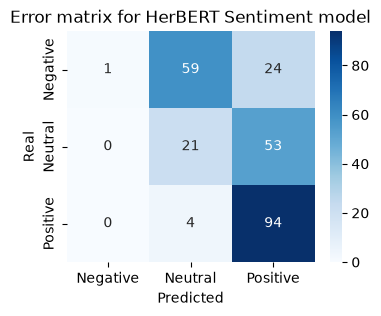


              precision    recall  f1-score   support

                   0.00      0.00      0.00         0
    Negative       1.00      0.00      0.01       300
     Neutral       0.25      0.17      0.20       117
    Positive       0.56      0.50      0.53       197
           [       0.00      0.00      0.00         0
          __       0.00      0.00      0.00         0

    accuracy                           0.20       614
   macro avg       0.30      0.11      0.12       614
weighted avg       0.71      0.20      0.21       614



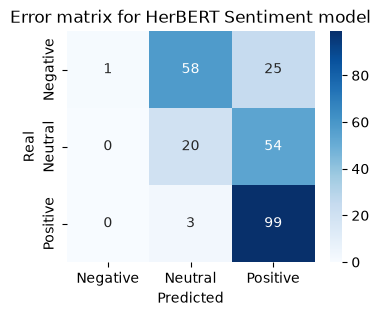

In [22]:


for preds in predictions:
    print(classification_report(df['target'], preds))

    plt.figure(figsize=(4, 3))
    cm = confusion_matrix(df['target'], preds, labels=['Negative', 'Neutral', 'Positive'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.ylabel('Real')
    plt.xlabel('Predicted')
    plt.title('Error matrix for HerBERT Sentiment model')
    plt.show()

    print()


In [28]:
print(predictions[0][:60])
print(predictions[1][:60])

['__', '__', '__', '__', '__', '__', '__', '', '', 'Positive', '', 'Positive', '__', '__', 'Positive', '', 'Positive', '__', '__', '__', '__', '__', '__', 'Positive', '__', '__', '__', 'Positive', 'Positive', '__', '__', '__', '__', '__', 'Neutral', '__', 'Positive', 'Positive', '__', '__', 'Positive', 'Positive', 'Neutral', '__', '__', '__', '__', 'Positive', 'Positive', '__', '__', '__', '__', '__', '__', '', 'Positive', '__', '__', '__']
['', '__', '__', '__', '__', 'Positive', '__', '', 'Positive', 'Positive', '', 'Positive', '__', '__', 'Positive', '', 'Positive', '__', '__', 'Neutral', '__', '__', '__', 'Positive', '__', '__', '__', 'Positive', 'Positive', '__', '__', 'Positive', '__', '__', 'Neutral', '__', 'Positive', 'Positive', '__', '__', 'Positive', 'Positive', 'Neutral', '__', '__', '__', '__', 'Positive', 'Positive', '__', '__', 'Positive', '__', 'Positive', '[', '', 'Positive', '__', '__', '__']
